Part 4 – Color Detection, Tracking, and Image Enhancement

In this section, we explore color-based image processing, real-time tracking, and image enhancement techniques using OpenCV. The key topics include:

Creating and visualizing HSV color spaces for color selection

Using color masking to isolate specific colors in images and videos

Detecting and tracking colored objects in real-time video streams

Replacing backgrounds using green screen removal

Enhancing image contrast with histogram equalization and CLAHE

Removing noise with uniform, Gaussian, and median blurring

Sharpening images using custom kernels

Extracting image gradients with custom and Sobel filters

By completing this part, you will gain practical skills for color segmentation, object tracking, background manipulation, and enhancing image quality—essential for real-time computer vision and image analysis applications.

### Importing Required Libraries  

In this part, we begin by importing the essential libraries:  

- **OpenCV (`cv2`)** → used for image processing and computer vision tasks.  
- **Matplotlib (`matplotlib.pyplot`)** → for plotting and visualizing images.  
- **NumPy (`numpy`)** → for array manipulations and numerical operations.  

These libraries provide the foundation for performing advanced image analysis in the upcoming steps.  


In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Visualizing the Hue Channel in HSV Color Space  

In this example, we create an image that demonstrates how the **Hue** component of the HSV (Hue, Saturation, Value) color space works:  

1. **Hue values (0–179 in OpenCV)** are generated using `np.linspace`.  
2. A matrix is built by repeating these hue values to form an image.  
3. **Saturation** and **Value** channels are set to maximum (255), ensuring full color intensity.  
4. The channels are merged into a single **HSV image** using `cv.merge`.  
5. The HSV image is then converted to **RGB** with `cv.cvtColor` for proper visualization in Matplotlib.  

The result is a gradient strip showing all hues, from red through green and blue, and back to red.  


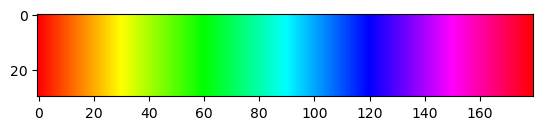

In [12]:
hue=np.linspace(0,179,180,dtype="uint8")
matrix_hue=np.array([hue]*30)

sat=np.ones_like(matrix_hue)*255
value=np.ones_like(matrix_hue)*255
colorful=cv.merge((matrix_hue,sat,value))

colorful1=cv.cvtColor(colorful,cv.COLOR_HSV2RGB)
plt.imshow(colorful1)

### Color Detection Using HSV and Masking  

This example demonstrates how to **detect and isolate specific colors** in an image using the HSV color space:  

1. The input image (`pepper.jpg`) is read and converted from **BGR to HSV**.  
2. A **color range** is defined with `lowerb` and `upperb` values (in this case, targeting yellow tones).  
3. `cv.inRange` creates a **binary mask**, where pixels within the color range are white and others are black.  
4. Using `cv.bitwise_and`, the mask is applied to the original image, keeping only the detected regions.  
5. The results are displayed:  
   - **Original image**  
   - **Mask (binary image)**  
   - **Masked image** showing only the selected color region  

This is a common technique in computer vision for **color-based object detection and segmentation**.  


(<matplotlib.image.AxesImage at 0x19b56233ed0>, Text(0.5, 1.0, 'masked image'))

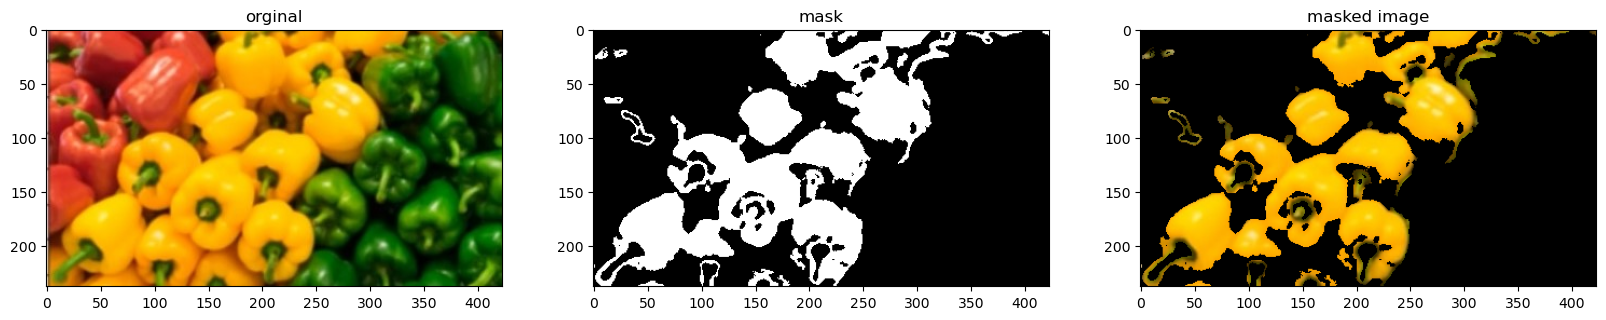

In [29]:
img=cv.imread("./Pictures/pepper.jpg")
img1=cv.cvtColor(img,cv.COLOR_BGR2HSV)
lowerb=(20,50,50)
upperb=(30,255,255)
mask=cv.inRange(img1,lowerb,upperb)
fig=plt.figure(figsize=[20,40])
plt.subplot(1,3,1);plt.imshow(img[:,:,::-1]),plt.title("orginal")
plt.subplot(1,3,2);plt.imshow(mask,cmap="gray"),plt.title("mask")
img3=cv.bitwise_and(img,img,mask=mask)
plt.subplot(1,3,3);plt.imshow(img3[:,:,::-1]),plt.title("masked image")

### Detecting Red Color in HSV Space  

Red is a special case in the HSV color space because it appears at **both ends of the hue spectrum**. To handle this:  

1. The image is converted from **BGR to HSV**.  
2. Two separate masks are created for red:  
   - `mask1` for lower hue values (0–15)  
   - `mask2` for upper hue values (165–179)  
3. The two masks are **combined** using addition to get the complete red region.  
4. `cv.bitwise_and` applies the combined mask to the original image, isolating the red areas.  
5. Results displayed:  
   - **Original image**  
   - **Combined red mask**  
   - **Masked image** showing detected red regions  

This method ensures that all shades of red are detected correctly, which is essential for **color-based segmentation and tracking tasks**.  


(<matplotlib.image.AxesImage at 0x19b597a0190>, Text(0.5, 1.0, 'masked image'))

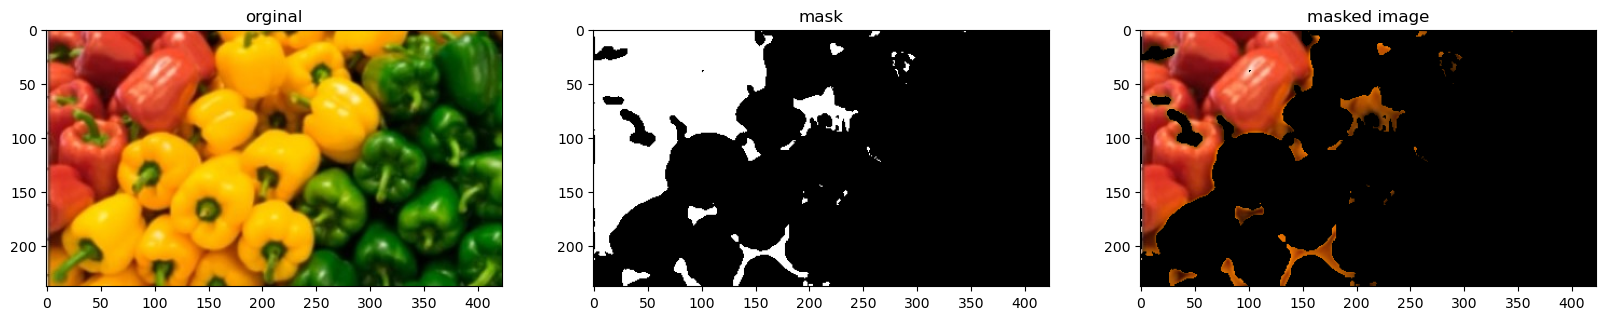

In [30]:
lowerb=(0,50,50)
upperb=(15,255,255)
mask1=cv.inRange(img1,lowerb,upperb)

lowerb=(165,50,50)
upperb=(179,255,255)
mask2=cv.inRange(img1,lowerb,upperb)

mask=mask1+mask2

fig=plt.figure(figsize=[20,40])
plt.subplot(1,3,1);plt.imshow(img[:,:,::-1]),plt.title("orginal")
plt.subplot(1,3,2);plt.imshow(mask,cmap="gray"),plt.title("mask")
img3=cv.bitwise_and(img,img,mask=mask)
plt.subplot(1,3,3);plt.imshow(img3[:,:,::-1]),plt.title("masked image")

### Detecting Blue Color in a Video  

This cell demonstrates **real-time color detection in a video**:  

1. **Video capture** is initialized with `cv.VideoCapture`.  
2. Each frame is converted from **BGR to HSV** for easier color detection.  
3. A **blue color range** is defined with lower `(110,50,50)` and upper `(140,255,255)` HSV values.  
4. `cv.inRange` creates a mask that highlights pixels within the blue range.  
5. `cv.bitwise_and` applies the mask to the original frame, isolating blue areas.  
6. The following are displayed in real-time:  
   - **Original frame**  
   - **Mask showing detected blue regions**  
   - **Masked frame** with only blue areas visible  
7. Press `Esc` to exit the loop and release resources.  

This approach is useful for **object tracking, color segmentation, and real-time video analysis**.  


In [4]:

cmp=cv.VideoCapture("./Videos/blue-track.mp4")

while True:
    
    ret,fram=cmp.read()

    if ret== False:
        break

    img=cv.cvtColor(fram,cv.COLOR_BGR2HSV)
    lowe=(110,50,50)
    upper=(140,255,255)
    mask=cv.inRange(img,lowe,upper)
    masked_fram=cv.bitwise_and(fram,fram,mask=mask)
    cv.imshow("mask",mask)
    cv.imshow("webcam",fram)
    cv.imshow("masked_fram",masked_fram)

    if cv.waitKey(1)==27:
        break

cv.destroyAllWindows()    
cmp.release()

### Tracking Blue Object in Video  

This cell demonstrates **real-time blue object tracking** in a video:  

1. **Video capture** is initialized using `cv.VideoCapture`.  
2. Each frame is converted from **BGR to HSV** for easier color detection.  
3. A **blue color range** is defined with lower `(110,50,50)` and upper `(140,255,255)` HSV values.  
4. `cv.inRange` generates a **mask** that highlights blue areas.  
5. `cv.findContours` detects all contours in the mask.  
6. `cv.minEnclosingCircle` finds the **smallest circle that encloses the largest blue contour**, giving the object’s position and size.  
7. `cv.circle` draws a **green circle** around the detected blue object on the original frame.  
8. The result is displayed in real-time with `cv.imshow`.  
9. Press `Esc` to exit and release the video capture.  

This method allows **real-time tracking of a colored object** for applications like robotics, motion analysis, or interactive systems.  


In [7]:
#track blue

cmp=cv.VideoCapture("./Videos/blue-track.mp4")
#we want to detect blue color
while True:
    
    ret,fram=cmp.read()

    if ret== False:
        break

    img=cv.cvtColor(fram,cv.COLOR_BGR2HSV)
    lowe=(110,50,50)
    upper=(140,255,255)
    mask=cv.inRange(img,lowe,upper)
    contours, _=cv.findContours(mask,cv.RETR_TREE,cv.CHAIN_APPROX_SIMPLE)
    center, radius=cv.minEnclosingCircle(contours[0])
    #cv.circle(fram,center,radius,(0,255,0),3)
    centers= int(center[0]),int(center[1])
    radius=int(radius)
    cv.circle(fram,centers,radius,(0,255,0),3)
    cv.imshow("webcam",fram)
   

    if cv.waitKey(1)==27:
        break

cv.destroyAllWindows()    
cmp.release()

### Green Screen (Chroma Key) Effect  

This cell demonstrates how to **replace a green background** in an image with another background:  

1. **Load the images**:  
   - `img` is the foreground image with a green background.  
   - `back` is the new background image.  

2. **Crop a small region** of the foreground to calculate the average green color in HSV space.  

3. **Define HSV range** for green:  
   - `lower = (63, 50, 50)`  
   - `upper = (83, 255, 255)`  

4. **Create masks**:  
   - `mask` highlights green areas.  
   - `mask_inv` highlights everything except green.  

5. **Resize background** to match the foreground dimensions.  

6. **Combine images using bitwise operations**:  
   - `new_back` keeps only the green areas from the background.  
   - `new_front` keeps only the non-green areas from the foreground.  
   - `cv.add` merges both to produce the final image.  

7. Display results using `matplotlib.pyplot` to show **original, mask, and final output**.  

This technique is commonly used in **video production and photography** to replace colored backgrounds seamlessly.


Text(0.5, 1.0, 'Output')

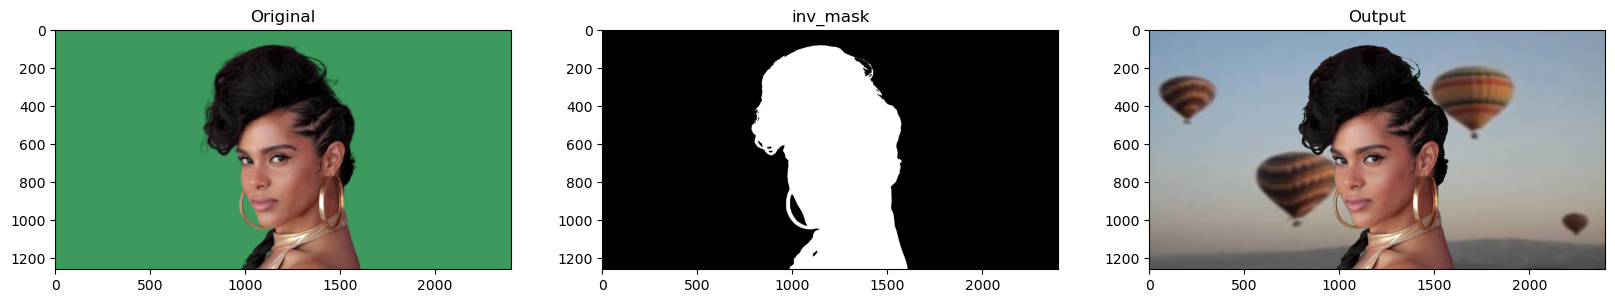

In [16]:
img=cv.imread("./Pictures/green_background_og_image.webp")
#plt.imshow(img[:,:,::-1])
fig=plt.figure(figsize=[20,40])
plt.subplot(1,3,1);plt.imshow(img[:,:,::-1]);plt.title("Original")

back=cv.imread("./Pictures/baloon.jpg")
crop_img=img[0:200,0:200,:]
hue=cv.cvtColor(crop_img,cv.COLOR_BGR2HSV)
np.mean(hue,(0,1))

lower=(63,50,50)
upper=(83,255,255)
hsv_img=cv.cvtColor(img,cv.COLOR_BGR2HSV)
mask=cv.inRange(hsv_img,lower,upper)
#plt.subplot(1,2,1);plt.imshow(mask,cmap="gray");plt.title("mask")

mask_inv=cv.bitwise_not(mask)
plt.subplot(1,3,2);plt.imshow(mask_inv,cmap="gray");plt.title("inv_mask")

h,w,_=img.shape
back1=cv.resize(back,(w,h))

new_back=cv.bitwise_and(back1,back1,mask=mask)
new_front=cv.bitwise_and(img,img,mask=mask_inv)
pic=cv.add(new_back,new_front)

plt.subplot(1,3,3);plt.imshow(pic[:,:,::-1]);plt.title("Output")

### Green Screen (Chroma Key) Video Replacement  

This cell demonstrates how to **replace a green background in a video** with a new background image:  

1. **Load resources**:  
   - `cap` reads the video with a green background.  
   - `back` is the new background image.  

2. **Process each frame**:  
   - Convert the frame to **HSV color space**.  
   - Define a **green range** (`lower = (63,50,50)`, `upper = (83,255,255)`).  
   - Create a **mask** for green areas and its inverse (`mask_inv`).  

3. **Resize the background** to match the frame dimensions.  

4. **Combine foreground and background**:  
   - `new_back` keeps only the green areas from the new background.  
   - `new_front` keeps only the non-green areas from the original frame.  
   - `cv.add` merges both to produce the final frame.  

5. **Display the result** with `cv.imshow` in real-time.  

6. **Cleanup**: Release the video capture and destroy all windows.  

This is an extension of the static image chroma keying technique to **video processing**, enabling dynamic background replacement.


In [2]:
back=cv.imread("./Pictures/baloon.jpg")
cap=cv.VideoCapture("./Pictures/female_green_screen.mp4")

while True:
    ret,fram=cap.read()
    if ret == False:
        break

    lower=(43,50,50)
    upper=(83,255,255)
    hsv_img=cv.cvtColor(fram,cv.COLOR_BGR2HSV)
    mask=cv.inRange(hsv_img,lower,upper)#green is withe  
    mask_inv=cv.bitwise_not(mask)
    h,w,_=fram.shape
    back1=cv.resize(back,(w,h))
    new_back=cv.bitwise_and(back1,back1,mask=mask)
    new_front=cv.bitwise_and(fram,fram,mask=mask_inv)
    pic=cv.add(new_back,new_front)
    cv.imshow("remove green",pic)
    if cv.waitKey(1)==27:
        break
    
cv.destroyAllWindows()
cap.release()
    

### Histogram Equalization and CLAHE  

This example shows how to **enhance image contrast** using two techniques:  

1. **Convert to grayscale**:  
   The input image (`hidden.png`) is converted from BGR to grayscale for intensity-based processing.  

2. **CLAHE (Contrast Limited Adaptive Histogram Equalization)**:  
   - Uses small tiles (`tileGridSize = (4,4)`) to enhance local contrast.  
   - Helps bring out details in darker or brighter regions.  

3. **Global Histogram Equalization**:  
   - Applies contrast stretching across the **entire image**.  
   - Spreads pixel intensities more evenly from 0–255.  

4. **Visualization**:  
   - Original grayscale image.  
   - Image after **CLAHE**.  
   - Image after **global histogram equalization**.    


### Histogram Equalization and CLAHE  

This example compares **global histogram equalization** with **CLAHE (Contrast Limited Adaptive Histogram Equalization)**:  

1. The input image (`hidden.png`) is first converted to grayscale.  
2. **CLAHE** enhances local contrast using small tiles, useful when details are hidden in darker or brighter regions.  
3. **Global histogram equalization** redistributes pixel intensities across the whole image.  

👉 In this case, the image already had **intensity extremes (0 and 255)**.  
That’s why **global histogram equalization worked better**, as it could stretch and balance the contrast more effectively than CLAHE.  


Text(0.5, 1.0, 'Histogram Equalization')

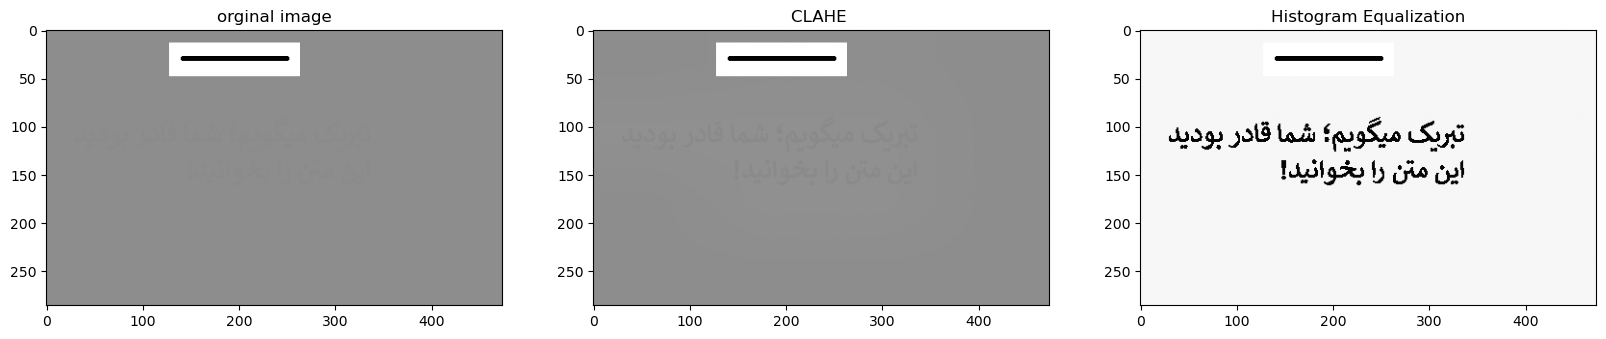

In [14]:
img=cv.imread("./Pictures/hidden.png")
fig=plt.figure(figsize=[20,30])
plt.subplot(1,3,1);plt.imshow(img,cmap="gray");plt.title("orginal image")
img=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
#plt.subplot(2,3,4);plt.hist(img.ravel(),256,(0,255));plt.title("hist")
lahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
cl1 = lahe.apply(img)
plt.subplot(1,3,2);plt.imshow(cl1,cmap="gray");plt.title("CLAHE ")
#plt.subplot(2,3,5);plt.hist(cl1.ravel(),256,(0,255));plt.title("hist")

img1=cv.equalizeHist(img)
plt.subplot(1,3,3);plt.imshow(img1,cmap="gray");plt.title("Histogram Equalization")
#plt.subplot(2,3,6);plt.hist(img1.ravel(),256,(0,255));plt.title("hist")

### Noise Reduction with Different Blurring Methods  

This example applies several filtering techniques to reduce noise in an image (`noisy.png`):  

1. **Uniform Blur (cv.blur)**  
   - Replaces each pixel with the average of its neighborhood.  
   - Simple but can blur edges too much.  

2. **Gaussian Blur (cv.GaussianBlur)**  
   - Uses a Gaussian kernel (weighted average).  
   - Smooths the image while preserving edges better than uniform blur.  

3. **Median Blur (cv.medianBlur)**  
   - Replaces each pixel with the median of neighboring pixels.  
   - Very effective against *salt-and-pepper noise*.  

4. *(Optional)* **Bilateral Filter (cv.bilateralFilter)**  
   - Smooths noise while keeping edges sharp.  
   - More computationally expensive but useful in detail-sensitive images.  

👉 In practice:  
- **Median Blur** is best for salt-and-pepper noise.  
- **Gaussian Blur** is a good general-purpose choice.  
- **Bilateral Filter** works when you need to preserve edges strongly.  


Text(0.5, 1.0, 'median bluring')

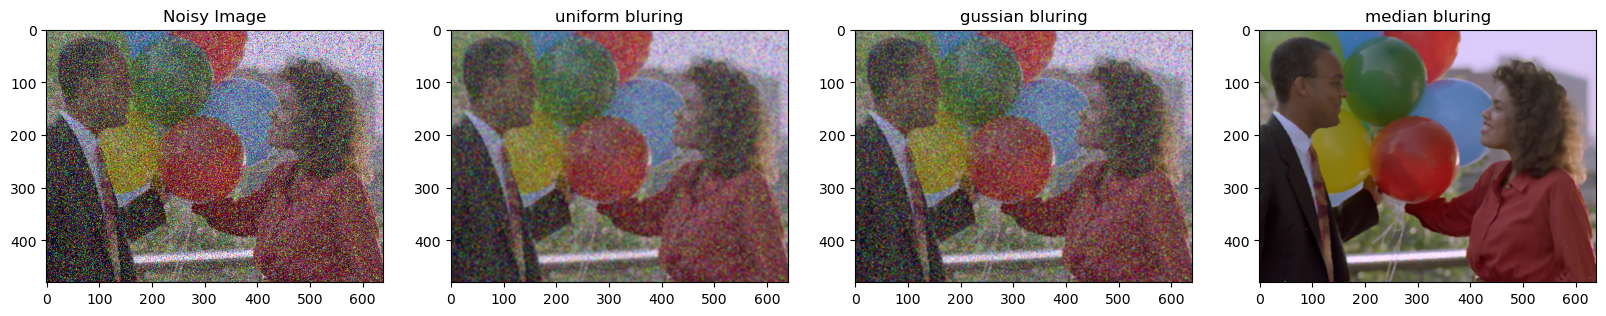

In [15]:
img=cv.imread("./Pictures/noisy.png")
blur_img=cv.blur(img,(5,5))
gusi_img=cv.GaussianBlur(img,(5,5),0)
median_img=cv.medianBlur(img,5)
#bi_img=cv.bilateralFilter(img,d=9, sigmaColor=75, sigmaSpace=75)
fig=plt.figure(figsize=[20,30])
plt.subplot(1,4,1);plt.imshow(img[:,:,::-1]);plt.title("Noisy Image")
plt.subplot(1,4,2);plt.imshow(blur_img[:,:,::-1]);plt.title("uniform bluring")
plt.subplot(1,4,3);plt.imshow(gusi_img[:,:,::-1]);plt.title("gussian bluring")
plt.subplot(1,4,4);plt.imshow(median_img[:,:,::-1]);plt.title("median bluring")

### Image Sharpening  

After noise reduction, we often want to **enhance details** in the image.  
This can be done using a **sharpening kernel** with `cv.filter2D`.  

- **Sharpening Kernel:**  

- The center value (`9`) emphasizes the original pixel.  
- Negative values around it subtract neighboring intensity, enhancing edges.  

- **Process:**  
1. Start with a denoised image (`median_img`).  
2. Apply the sharpening kernel.  
3. The result highlights edges and fine details, making the image look clearer.  

👉 Sharpening is especially useful after **blurring or denoising** to recover edge information.  

### 🔎 How the Sharpening Filter Works  

The sharpening kernel used is:  


#### 1. Center Pixel Weight (9)
- The middle value corresponds to the **current pixel**.  
- Giving it a large weight (`9`) makes the center pixel strongly influence the output.  

#### 2. Neighboring Pixels (-1)
- The surrounding values are **negative**.  
- They subtract the intensity of neighboring pixels from the center.  

#### 3. Effect on Flat Regions
- If all pixels in the neighborhood are similar (e.g., a smooth surface),  
  the subtraction cancels out most of the added intensity.  
- Result: flat areas stay nearly unchanged.  

#### 4. Effect on Edges / Details
- At edges or fine details, the center pixel is **different from its neighbors**.  
- The subtraction emphasizes these differences, making them stronger (brighter or darker).  
- This makes the **edges appear sharper**.  

---

### ⚖️ In simple terms:
- **Flat regions → remain almost unchanged.**  
- **Edges & details → differences are boosted, so they stand out more.**  

This is why the filter acts like a **high-pass filter**, highlighting rapid intensity changes such as **edges and fine details**.  



Text(0.5, 1.0, 'sharp image')

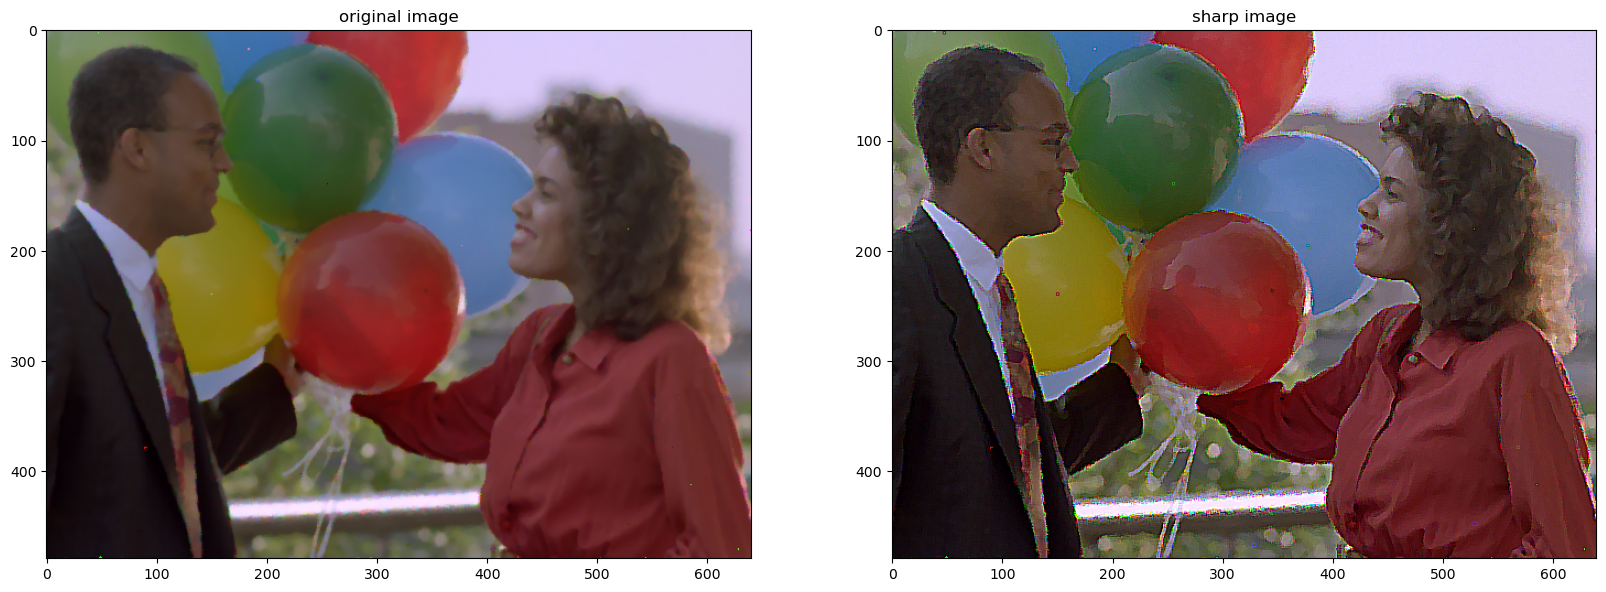

In [17]:
#image sharpening
best_img=median_img
kernel = np.array([[-1, -1, -1],
                   [-1,  9, -1],
                   [-1, -1, -1]])
sharp_img=cv.filter2D(best_img,-1,kernel)
fig=plt.figure(figsize=[20,30])
plt.subplot(1,2,1);plt.imshow(best_img[:,:,::-1]);plt.title("original image")
plt.subplot(1,2,2);plt.imshow(sharp_img[:,:,::-1]);plt.title("sharp image")

### 🌊 Gradient Filtering  

In this step, we use the following kernel to extract gradients:  


#### 🔎 How it works:
1. **Horizontal Difference**  
   - The kernel subtracts pixel intensity on the **left** from the **right**.  
   - This highlights changes in brightness along the **x-direction** (horizontal edges).  

2. **Flat Regions**  
   - If pixel values are similar across neighbors, the difference is close to zero → results in **dark/black regions**.  

3. **Edges / Transitions**  
   - If there’s a big difference between left and right pixels, the output is large → edges appear **bright**.  

---

### ⚖️ In simple terms:
- The filter computes the **rate of change of intensity** in the horizontal direction.  
- It acts like a **derivative operator**, detecting edges.  
- This is why the output image looks like a **gradient map**, where edges and details are visible in gray/white, and smooth regions are dark.  


Text(0.5, 1.0, 'gradient')

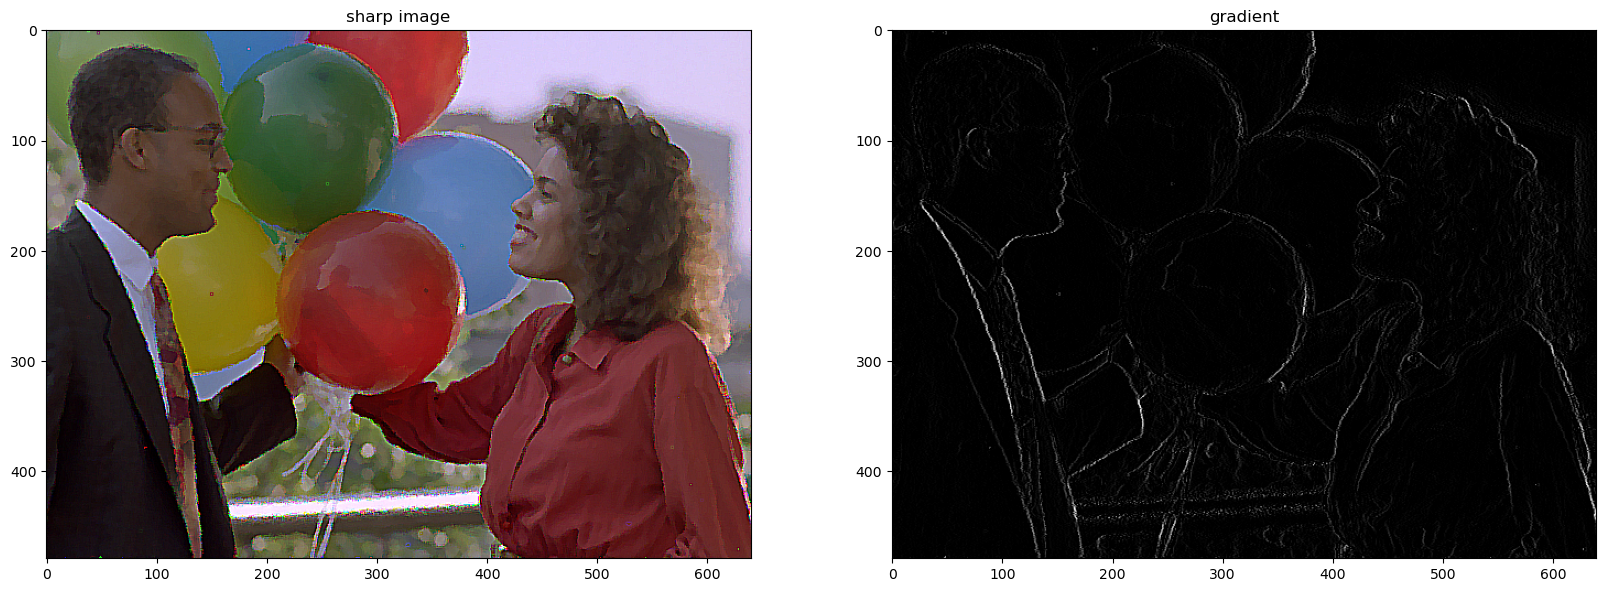

In [33]:
kernel=np.array([[0,0,0],
       [-1/2,0,1/2],
       [0,0,0]])
sharp_img1=cv.cvtColor(sharp_img,cv.COLOR_BGR2GRAY)
gra_img=cv.filter2D(sharp_img1,-1,kernel)
fig=plt.figure(figsize=[20,30])
plt.subplot(1,2,1);plt.imshow(sharp_img[:,:,::-1]);plt.title("sharp image")
plt.subplot(1,2,2);plt.imshow(gra_img,cmap="gray");plt.title("gradient")

Text(0.5, 1.0, 'gradient')

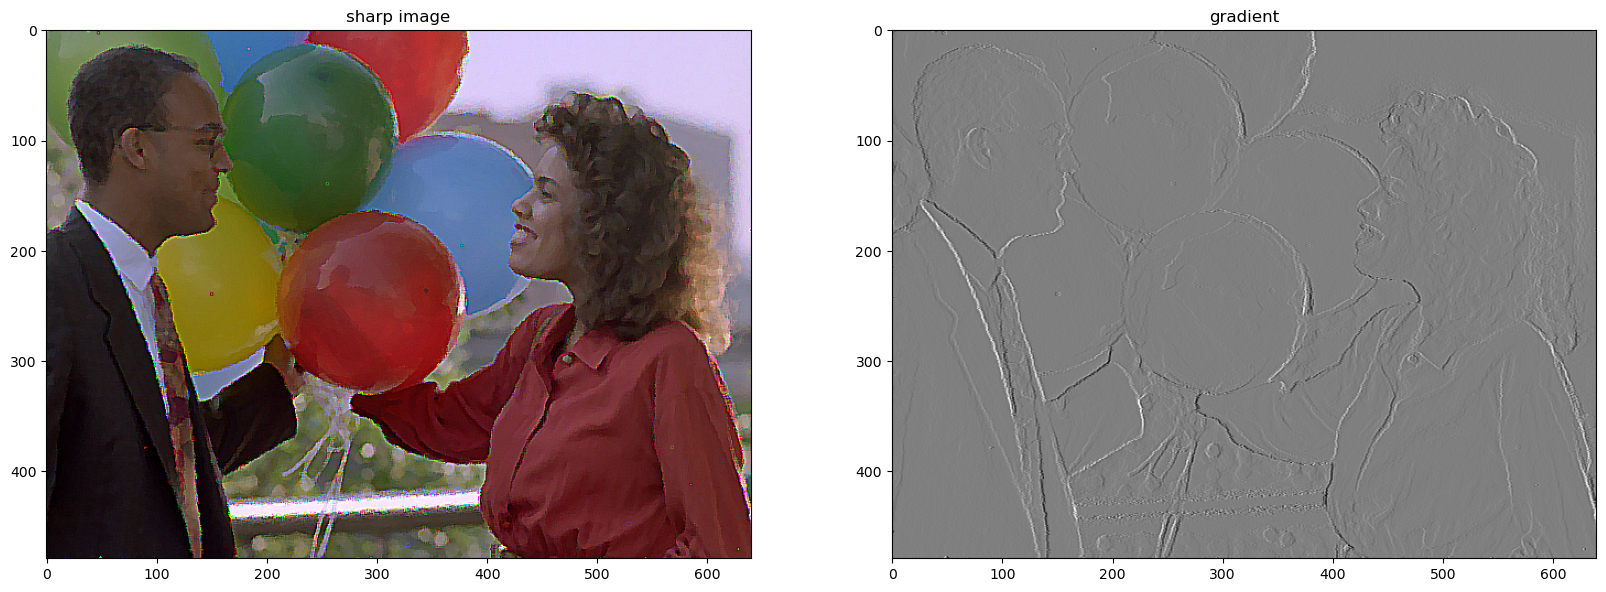

In [39]:
gra_img=cv.filter2D(sharp_img1,cv.CV_64F,kernel)
fig=plt.figure(figsize=[20,30])
plt.subplot(1,2,1);plt.imshow(sharp_img[:,:,::-1]);plt.title("sharp image")
plt.subplot(1,2,2);plt.imshow(gra_img,cmap="gray");plt.title("gradient")

### 🧭 Sobel Edge Detection  

The **Sobel operator** is a popular edge-detection method that uses derivatives to highlight regions of rapid intensity change. It applies convolution with special kernels to capture gradients in different directions.  

#### 🔎 How it works:
1. **Sobel X (`dx=1, dy=0`)**  
   - Detects intensity changes in the **horizontal direction**.  
   - Highlights **vertical edges**.  

2. **Sobel Y (`dx=0, dy=1`)**  
   - Detects intensity changes in the **vertical direction**.  
   - Highlights **horizontal edges**.  

3. **Sobel XY (`dx=1, dy=1`)**  
   - Combines both x and y derivatives.  
   - Highlights **diagonal edges** and captures more complex transitions.  

---

### ⚖️ In simple terms:
- **Sobel X → vertical edges**  
- **Sobel Y → horizontal edges**  
- **Sobel XY → diagonal + combined edges**  

This makes the Sobel filter very useful for detecting the **structure and outline** of objects in an image.  


Text(0.5, 1.0, 'sobel xy')

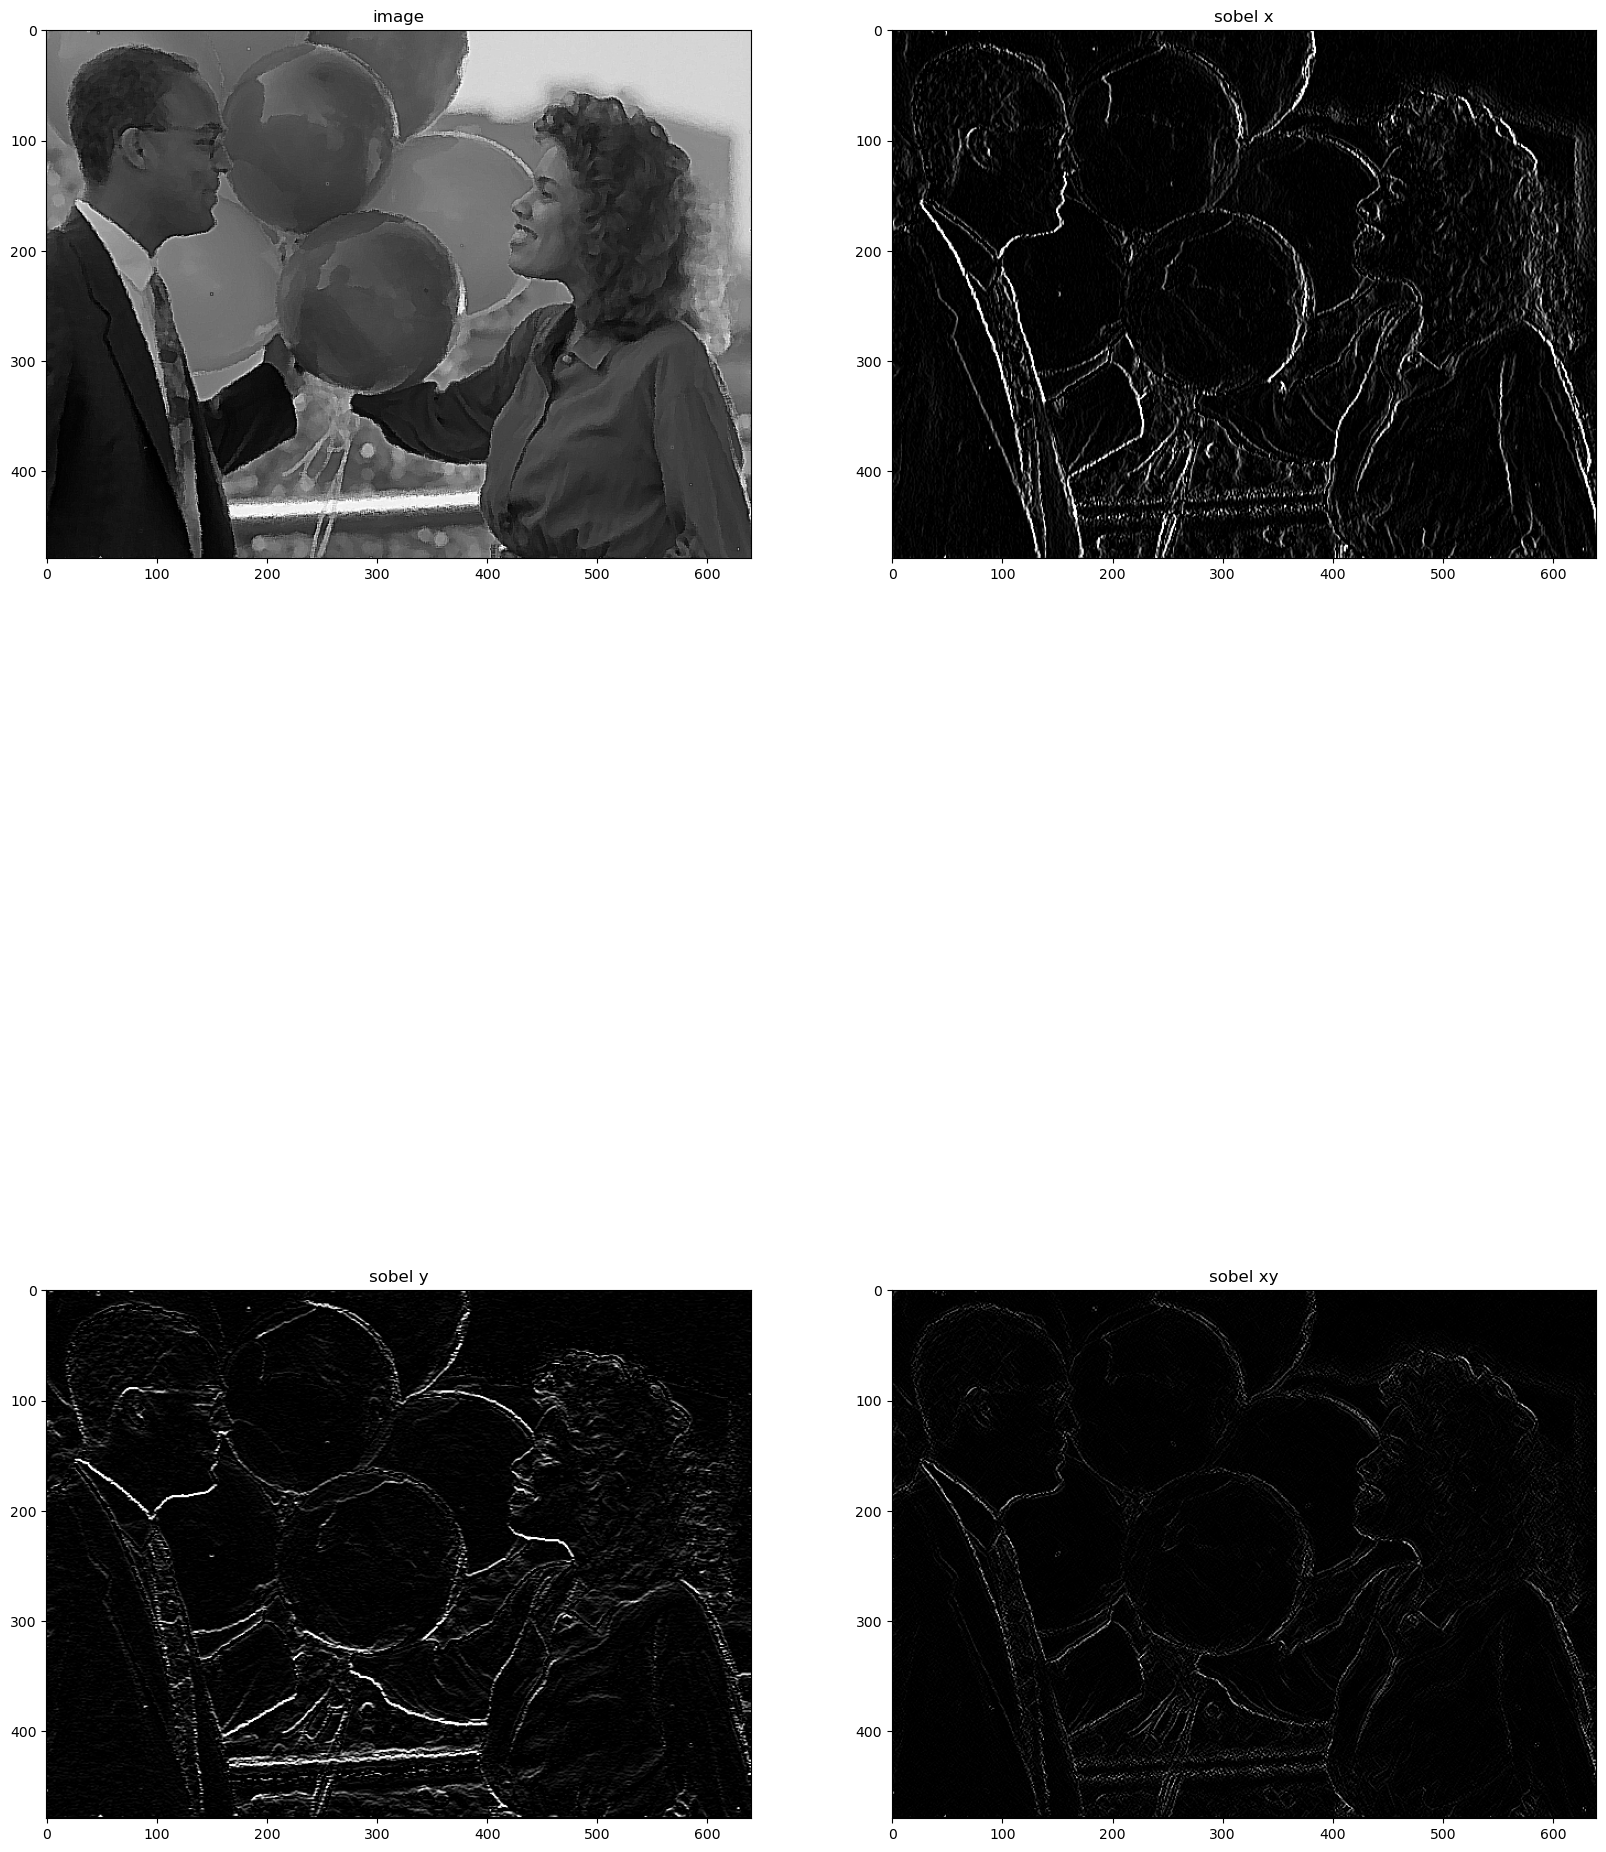

In [42]:
sobel_x=cv.Sobel(sharp_img1,-1,1,0)
sobel_y=cv.Sobel(sharp_img1,-1,0,1)
sobel_xy=cv.Sobel(sharp_img1,-1,1,1)
fig=plt.figure(figsize=[20,30])
plt.subplot(2,2,1);plt.imshow(sharp_img1,cmap="gray");plt.title("image")
plt.subplot(2,2,2);plt.imshow(sobel_x,cmap="gray");plt.title("sobel x")
plt.subplot(2,2,3);plt.imshow(sobel_y,cmap="gray");plt.title("sobel y")
plt.subplot(2,2,4);plt.imshow(sobel_xy,cmap="gray");plt.title("sobel xy")